## 1. Introduction

Rossmann operates over 3,000 drug stores across Europe. Sales are influenced by factors such as promotions, competition, holidays, and seasonality.

This project aims to analyze historical sales data and build a predictive model to forecast daily sales.


## Problem Statement

Retail businesses need accurate sales forecasts to optimize inventory, staffing, and marketing strategies.

However, sales are affected by multiple dynamic factors such as promotions, holidays, and competition. The challenge is to build a model that can accurately predict daily sales for each store.


## Objectives

* Analyze historical sales data to identify patterns and trends
* Understand the impact of promotions, holidays, and competition on sales
* Build a regression model to predict daily sales
* Evaluate model performance using appropriate metrics (RMSE, R²)


## 2. Data Understanding

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
train = pd.read_csv('../data/raw/train.csv')
store = pd.read_csv('../data/raw/store.csv')

df = pd.merge(train, store, on='Store', how='left')

<ipython-input-2-890552704c6b>:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/raw/train.csv')


In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df.shape

(1017209, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [6]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [7]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

## Data Description

The dataset contains 1,017,209 records and 18 features after merging train and store datasets.

### Sales & Customers

* **Sales**: Daily sales revenue (Target Variable)
* **Customers**: Number of customers per day

### Store Information

* **Store**: Unique store ID
* **StoreType**: Type of store (a, b, c, d)
* **Assortment**: Assortment level (a = basic, b = extra, c = extended)

### Time & Date

* **Date**: Date of the record
* **DayOfWeek**: Day of the week (1 = Monday, 7 = Sunday)

### Promotions

* **Promo**: Indicates if a promotion was active (1 = Yes, 0 = No)
* **Promo2**: Indicates continuous promotion
* **Promo2SinceWeek**: Week when Promo2 started
* **Promo2SinceYear**: Year when Promo2 started
* **PromoInterval**: Months when Promo2 is active

### Holidays

* **StateHoliday**: Indicates state holidays (a, b, c, 0 = none)
* **SchoolHoliday**: Indicates school holidays (1 = Yes, 0 = No)

### Store Operation

* **Open**: Whether the store was open (1 = open, 0 = closed)

### Competition

* **CompetitionDistance**: Distance to nearest competitor
* **CompetitionOpenSinceMonth**: Month when competitor opened
* **CompetitionOpenSinceYear**: Year when competitor opened


In [8]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

## 3. Exploratory Data Analysis(EDA)

### SALES DISTRIBUTION

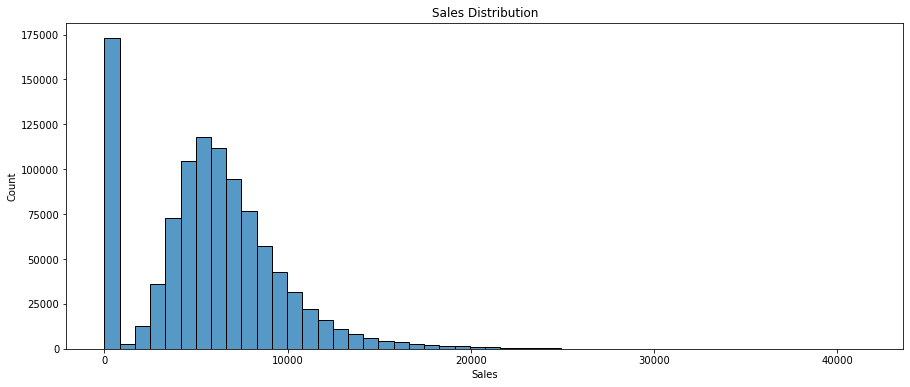

In [9]:
plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='Sales',  bins=50) #Plotting histogram of sales (interval of 50)
plt.title("Sales Distribution") # title 
plt.show() # displaying the plot

The sales distribution appears right-skewed, indicating that most stores generate moderate sales while a smaller number of stores generate extremely high sales. This suggests the presence of outliers and non-normality in the target variable.


### Sales over time

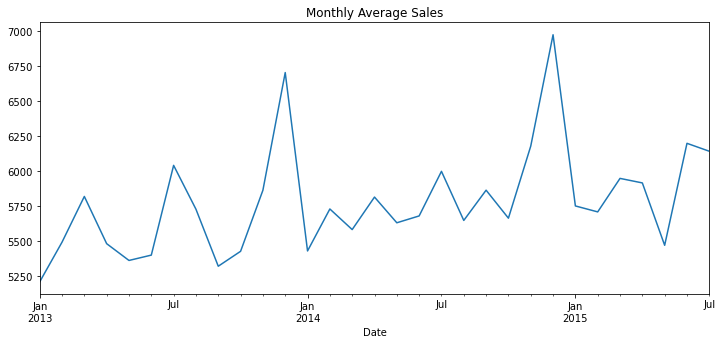

In [10]:
df['Date'] = pd.to_datetime(df['Date']) # convert the date column from string to real date object
 

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].mean() # group average sales by month 
plt.figure(figsize=(10, 6))# set the dimentions of drawing canvas
monthly_sales.plot(figsize=(12,5), title="Monthly Average Sales") # create a line chart ,title and figure size (w= 12 , h= 5)
plt.show() # display the graph


The monthly average sales trend shows noticeable fluctuations across different months, indicating seasonal patterns in customer purchasing behavior. Certain months exhibit significantly higher sales, likely influenced by promotions, holidays, or increased demand periods. The absence of a consistent upward or downward trend suggests that temporal and seasonal factors play a major role in sales performance.


### Promotion impact on sales

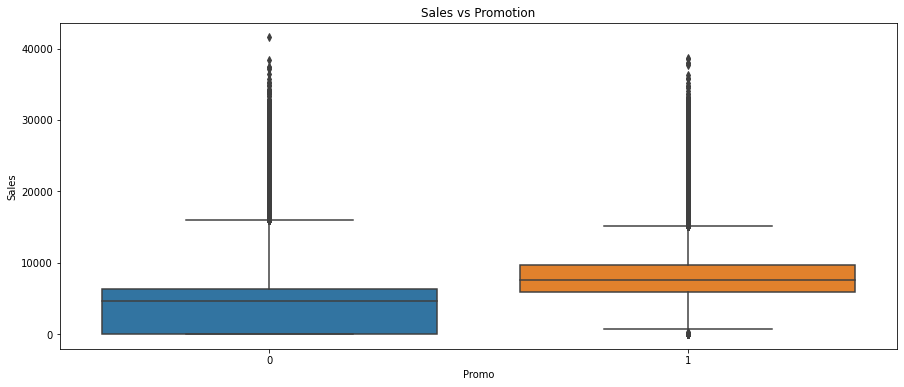

In [11]:
# Promotion Impact on Sales
# Calculate the average sales for each promotion category
# Promo = 0 means no promotion
# Promo = 1 means promotion was active
promo_sales_mean = df.groupby('Promo')['Sales'].mean()
plt.figure(figsize=(15, 6))

# Create a boxplot to compare sales distribution with and without promotions
# data=df tells Seaborn which DataFrame to use
# x='Promo' places promotion categories on the x-axis
# y='Sales' places sales values on the y-axis
sns.boxplot(data=df, x='Promo', y='Sales')

# Add chart title
plt.title("Sales vs Promotion")

# Display the plot
plt.show()

The boxplot shows that stores with active promotions generally achieve higher sales compared to stores without promotions. The median sales value is higher when Promo = 1, indicating that promotions positively influence sales performance. However, both groups contain several high-value outliers, suggesting that other factors such as store type, customer traffic, holidays, or location may also contribute to unusually high sales.

### Sales Distribution by Day of Week

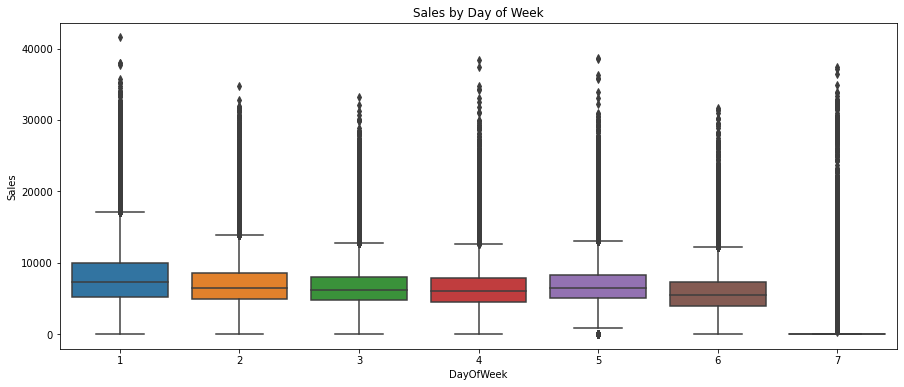

In [12]:
# Sales Distribution by Day of Week

# set the dimentions of drawing canvas 
# Create a boxplot to analyze sales distribution across days of the week
# DayOfWeek values:
# 1 = Monday
# 7 = Sunday
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='DayOfWeek', y='Sales')

# Add chart title
plt.title("Sales by Day of Week")

# Display the plot
plt.show()

The boxplot shows that sales vary across different days of the week. Monday appears to have relatively higher median sales compared to other weekdays, while Sunday shows very low sales for many stores, likely because many stores are closed. The presence of many outliers across all days suggests that factors such as promotions, holidays, and store characteristics may also influence high sales values.

### Correlation Matrix

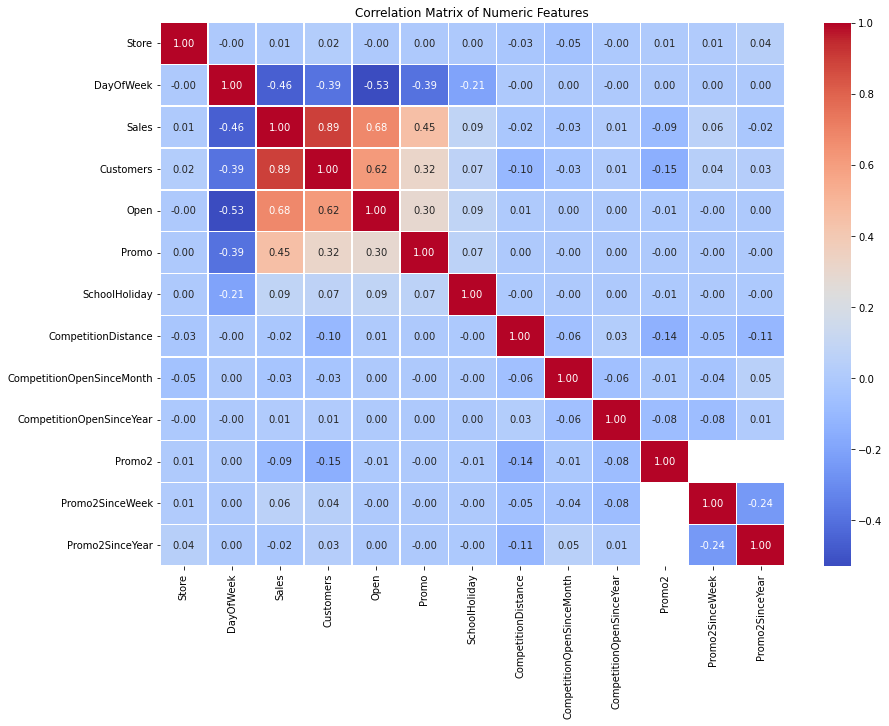

In [13]:
# Select only numeric columns from the DataFrame
# This removes text/categorical columns because correlation works only with numeric data
numeric_df = df.select_dtypes(include='number')

# Create a new figure for the heatmap
# figsize=(14, 10) means width = 14 inches and height = 10 inches
plt.figure(figsize=(14, 10))

# Create a heatmap to visualize correlations between numeric features
sns.heatmap(
    # Calculate the correlation matrix for all numeric columns
    # Correlation values range from -1 to +1
    data=numeric_df.corr(),

    # Show the correlation values inside each heatmap cell
    annot=True,

    # Format correlation numbers to 2 decimal places
    fmt=".2f",

    # Use the coolwarm color palette
    # Blue usually represents negative correlation
    # Red usually represents positive correlation
    cmap="coolwarm",

    # Add small lines between heatmap cells for better readability
    linewidths=0.5
)

# Add a title to the heatmap
plt.title("Correlation Matrix of Numeric Features")

# Display the heatmap
plt.show()

The correlation heatmap shows that Customers has the strongest positive correlation with Sales, indicating that customer traffic is the most influential numeric factor in daily sales. Open also has a strong positive relationship with Sales because closed stores usually record zero sales. Promo shows a moderate positive correlation with Sales, confirming that promotional activity is associated with higher sales. DayOfWeek has a negative relationship with Sales, suggesting that sales tend to decrease toward the end of the week, especially on Sundays.

### Data Preprocessing

In [14]:
# Create a copy of the dataset for cleaning
df_clean = df.copy()

In [15]:
#checking missing values in each column
df_clean.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [16]:
# Create missing value summary table
missing_table = pd.DataFrame({
    'Missing Values': df_clean.isnull().sum(),
    'Missing Percentage': (
        df_clean.isnull().sum() / len(df_clean)
    ) * 100
})

# Sort table
missing_table.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Values,Missing Percentage
PromoInterval,508031,49.943620
Promo2SinceYear,508031,49.943620
Promo2SinceWeek,508031,49.943620
CompetitionOpenSinceYear,323348,31.787764
CompetitionOpenSinceMonth,323348,31.787764
CompetitionDistance,2642,0.259730
DayOfWeek,0,0.000000
Promo2,0,0.000000
Assortment,0,0.000000
Store,0,0.000000


In [17]:
# Fill missing CompetitionDistance with median (very small missing percentage)
df_clean['CompetitionDistance'] = df_clean['CompetitionDistance'].fillna(
    df_clean['CompetitionDistance'].median()
)

# Fill missing competition opening month/year with 0 (Large missing percentage)
df_clean['CompetitionOpenSinceMonth'] = df_clean['CompetitionOpenSinceMonth'].fillna(0)

df_clean['CompetitionOpenSinceYear'] = df_clean['CompetitionOpenSinceYear'].fillna(0)

# Fill missing Promo2-related columns with 0 and None(large missing percentage)
df_clean['Promo2SinceWeek'] = df_clean['Promo2SinceWeek'].fillna(0)

df_clean['Promo2SinceYear'] = df_clean['Promo2SinceYear'].fillna(0)

df_clean['PromoInterval'] = df_clean['PromoInterval'].fillna('None')

In [18]:
# Calculate missing percentage for all columns
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean)
) * 100

# Sort from highest to lowest
missing_percentage.sort_values(ascending=False)

Store                        0.0
DayOfWeek                    0.0
Promo2SinceYear              0.0
Promo2SinceWeek              0.0
Promo2                       0.0
CompetitionOpenSinceYear     0.0
CompetitionOpenSinceMonth    0.0
CompetitionDistance          0.0
Assortment                   0.0
StoreType                    0.0
SchoolHoliday                0.0
StateHoliday                 0.0
Promo                        0.0
Open                         0.0
Customers                    0.0
Sales                        0.0
Date                         0.0
PromoInterval                0.0
dtype: float64

In [19]:
#checkiing data types
df_clean.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

In [20]:
# Convert float columns back to integer after filling missing values
# Because these variables represent:

# years
# months
# weeks

#which are: discrete integer values 
df_clean['CompetitionOpenSinceMonth'] = (
    df_clean['CompetitionOpenSinceMonth']
    .astype(int)
)

df_clean['CompetitionOpenSinceYear'] = (
    df_clean['CompetitionOpenSinceYear']
    .astype(int)
)

df_clean['Promo2SinceWeek'] = (
    df_clean['Promo2SinceWeek']
    .astype(int)
)

df_clean['Promo2SinceYear'] = (
    df_clean['Promo2SinceYear']
    .astype(int)
)

After handling missing values, several temporal columns that had been automatically converted to float type were converted back to integer type because they represent discrete values such as weeks, months, and years. The Date column remained in datetime format to support time-series analysis and feature engineering.

In [21]:
#checkiing data types
df_clean.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth             int32
CompetitionOpenSinceYear              int32
Promo2                                int64
Promo2SinceWeek                       int32
Promo2SinceYear                       int32
PromoInterval                        object
dtype: object

In [22]:
#checking duplicates
df_clean.duplicated().sum()

0

In [23]:
#checking outliers
# Calculate first quartile (25%)
Q1 = df_clean['Sales'].quantile(0.25)

# Calculate third quartile (75%)
Q3 = df_clean['Sales'].quantile(0.75)

# Calculate interquartile range
IQR = Q3 - Q1

# Calculate lower boundary
lower_bound = Q1 - 1.5 * IQR

# Calculate upper boundary
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_clean[
    (df_clean['Sales'] < lower_bound) |
    (df_clean['Sales'] > upper_bound)
]

# Count outliers
print("Number of outliers:", outliers.shape[0])

Number of outliers: 26694


Outlier detection using the IQR method identified approximately 26,694 outlier observations in the Sales variable, representing about 2.6% of the dataset. These outliers likely reflect legitimate business situations such as promotional periods, holidays, or exceptionally high-performing stores rather than data errors. Therefore, outliers were retained for further analysis instead of being removed immediately.

In [24]:
# Select object and category data types
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

# Print unique values for each category column
for col in cat_cols:
    print(f"--- Unique values for {col} ---")
    print(df_clean[col].unique())

--- Unique values for StateHoliday ---
['0' 'a' 'b' 'c' 0]
--- Unique values for StoreType ---
['c' 'a' 'd' 'b']
--- Unique values for Assortment ---
['a' 'c' 'b']
--- Unique values for PromoInterval ---
['None' 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


In [25]:
# Standardize categorical columns
df_clean['StateHoliday'] = (
    df_clean['StateHoliday']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_clean['StoreType'] = (
    df_clean['StoreType']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_clean['Assortment'] = (
    df_clean['Assortment']
    .astype(str)
    .str.strip()
    .str.lower()
)

Categorical columns were inspected for inconsistencies and missing values. The StateHoliday column contained mixed data types ('0' and 0), which were standardized by converting all values to lowercase strings. StoreType and Assortment were already consistent but were standardized as a precaution. PromoInterval contained logical missing values associated with stores not participating in Promo2, and these missing values were replaced with "None".

In [26]:
# Check negative sales
(df_clean['Sales'] < 0).sum()

# Check negative customers
(df_clean['Customers'] < 0).sum()

0

In [27]:
# Count open and closed stores
df_clean['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [28]:
# Analyze sales when stores are closed
df_clean[df_clean['Open'] == 0]['Sales'].describe()

count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

In [29]:
# Keep only open stores
df_clean = df_clean[df_clean['Open'] == 1]

In [30]:
# Remove rows with zero sales
df_clean = df_clean[df_clean['Sales'] > 0]

No negative values were found in the Sales or Customers columns, confirming that the dataset is logically consistent. Analysis of the Open column showed that closed stores consistently recorded zero sales, indicating that store operating status strongly influences sales performance. Therefore, closed stores were removed from the dataset to allow the model to focus on predicting sales behavior for actively operating stores.

In [31]:
# Shape after cleaning
print("Cleaned Shape:", df_clean.shape)

Cleaned Shape: (844338, 18)


In [32]:
# Save cleaned dataset
df_clean.to_csv(
    '../data/processed/rossmann_cleaned.csv',
    index=False
)

In [33]:
# Final missing value check
df_clean.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [34]:
# Final dataset information
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  object        
 10  Assortment                 844338 non-null  object        
 11  CompetitionDistance        844338 non-null  float64     

In [35]:
df_clean.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,None
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,None
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,None


### Feature Engineering

In [36]:
# Extract year from date
df_clean['Year'] =df_clean['Date'].dt.year
# Extract month
df_clean['Month'] = df_clean['Date'].dt.month

# Extract day
df_clean['Day'] = df_clean['Date'].dt.day

# Extract weekday
df_clean['Weekday'] = df_clean['Date'].dt.weekday

# Extract week number
df_clean['WeekOfYear'] = df_clean['Date'].dt.isocalendar().week
# Convert WeekOfYear to integer
df_clean['WeekOfYear'] = (
    df_clean['WeekOfYear']
    .astype(int)
)

# Extract quarter
df_clean['Quarter'] = df_clean['Date'].dt.quarter
# Create weekend indicator
df_clean['IsWeekend'] = (
    df_clean['Weekday'] >= 5
).astype(int)

In [37]:
# Calculate competition age in years
df_clean['CompetitionAge'] = (
    df_clean['Year']
    - df_clean['CompetitionOpenSinceYear']
)

In [38]:
(df_clean['CompetitionAge']<0).sum()

43404

In [39]:
# Replace negative competition ages with 0
df_clean['CompetitionAge'] = (
    df_clean['CompetitionAge']
    .clip(lower=0)
)

In [40]:
(df_clean['CompetitionAge']<0).sum()

0

In [41]:
# Calculate promo duration
df_clean['PromoDuration'] = (
    df_clean['Year']
    - df_clean['Promo2SinceYear']
)

In [42]:
(df_clean['PromoDuration']<0).sum()

34349

In [43]:
# Replace negative promo duration with 0
df_clean['PromoDuration'] = (
    df_clean['PromoDuration']
    .clip(lower=0)
)

In [44]:
# Create holiday indicator
df_clean['IsHoliday'] = (
    df_clean['StateHoliday'] != '0'
).astype(int)

In [45]:
# Drop original Date column
df_clean = df_clean.drop('Date', axis=1)


In [46]:
# Drop Store column
df_clean = df_clean.drop('Store', axis=1)

In [47]:
# Drop Open column
df_clean = df_clean.drop('Open', axis=1)

In [48]:
df_clean.columns

Index(['DayOfWeek', 'Sales', 'Customers', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month',
       'Day', 'Weekday', 'WeekOfYear', 'Quarter', 'IsWeekend',
       'CompetitionAge', 'PromoDuration', 'IsHoliday'],
      dtype='object')

In [49]:
df_clean.shape

(844338, 25)

Feature engineering was performed to transform raw variables into more meaningful predictive features. Time-based features such as month, weekday, quarter, and weekend indicators were extracted from the Date column to capture seasonality and temporal sales behavior. Competition and promotion duration features were also created to better represent long-term business effects. Categorical variables were encoded using one-hot encoding to prepare the dataset for machine learning models.

 ### Modeling 

In [50]:
# Define target variable
y = df_clean['Sales']

# Define feature variables
X = df_clean.drop(columns=['Sales'])

In [51]:
# Identify categorical columns for OneHotEncoding
categorical_cols = [
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

# Identify numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns

In [52]:
# Create preprocessing steps
# OneHotEncoder converts categorical columns into numeric dummy variables
# StandardScaler scales numerical columns for Linear Regression
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [53]:
# Create Linear Regression pipeline
# Step 1: preprocess data
# Step 2: train Linear Regression model
linear_regression_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [54]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
# Train the pipeline
linear_regression_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['StateHoliday', 'StoreType',
                                                   'Assortment',
                                                   'PromoInterval']),
                                                 ('num', StandardScaler(),
                                                  Index(['DayOfWeek', 'Customers', 'Promo', 'SchoolHoliday',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'Year', 'Month', 'Day', 'Weekday', 'WeekOfYear',
       'Quarter', 'IsWeekend', 'CompetitionAge', 'PromoDuration', 'IsHoliday'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [56]:
# Make predictions
y_pred = linear_regression_pipeline.predict(X_test)

### Evaluation

In [57]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 931.4168842985326
RMSE: 1278.7950580976672
R² Score: 0.8305295011372806


In [58]:
cv_scores = cross_val_score(
    linear_regression_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross-validation R² scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

Cross-validation R² scores: [0.81733635 0.83256216 0.8298645  0.82948046 0.83730384]
Average CV R²: 0.8293094627915412


In [59]:
# Calculate residuals
residuals = y_test - y_pred


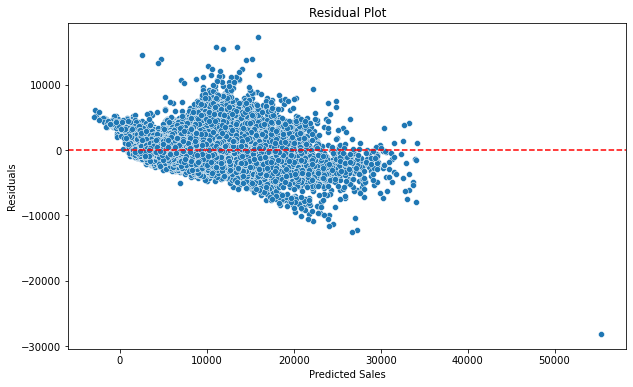

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

## Business Insights

Promotions

Stores with promotions generate higher sales.

Customers

Customer count is the strongest predictor of sales.

Seasonality

Sales vary by month and day of week.

Competition

Competition distance has measurable impact on store performance.

## Conclution
This project analyzed over one million Rossmann store sales records to identify the factors influencing daily sales and to develop a predictive Linear Regression model. Exploratory analysis revealed that customer traffic, promotions, store operations, and seasonal factors significantly impact sales performance.

Data cleaning addressed missing values, categorical inconsistencies, and closed-store records. Feature engineering created meaningful temporal and business-related variables such as CompetitionAge, PromoDuration, and holiday indicators.

The final Linear Regression model demonstrated the ability to explain a substantial portion of sales variability, while residual analysis highlighted opportunities for further improvement through advanced modeling techniques. Overall, the project provides actionable business insights that can support inventory planning, workforce allocation, promotional strategy, and operational decision-making.


In [72]:
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

print("Prediction sample:")
print(y_pred[:10])

print("Actual sample:")
print(y_test.iloc[:10].values)

R²: 0.8305295011372806
RMSE: 1278.7950580976672
MAE: 931.4168842985326
Prediction sample:
[ 6590.75402832  8610.01245117 10993.43548584  8562.28808594
  8231.25158691  5727.94146729  7161.44940186 14467.58746338
  5555.99700928  5461.79248047]
Actual sample:
[ 5934  7800  9111  7831 10046  6819  5570 15060  5856  4831]


In [73]:
import os

print(os.path.abspath("../models/rossmann_pipeline.pkl"))

c:\Users\Hp\Documents\Rossman store project\models\rossmann_pipeline.pkl


## Deployment

In [66]:
import joblib

joblib.dump(
    linear_regression_pipeline,
    '../models/rossmann_pipeline.pkl'
)

['../models/rossmann_pipeline.pkl']

In [75]:
import joblib

joblib.dump(
    {
        "model": linear_regression_pipeline,
        "columns": X.columns.tolist()
    },
    "../models/rossmann_pipeline.pkl"
)

['../models/rossmann_pipeline.pkl']